# Tyche Example for Catalytic Fast Pyrolysis

## Set up.

### One only needs to execute the following line once, in order to make sure recent enough packages are installed.

In [1]:
#!pip install 'numpy>=1.17.2' 'pandas>=0.25.1'

### Import packages.

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath("../../../src"))

In [3]:
import numpy             as np
import matplotlib.pyplot as pl
import pandas            as pd
import re                as re
import scipy.stats       as st
import seaborn           as sb

# The `tyche` package is located at <https://github.com/NREL/portfolio/tree/master/production-function/framework/src/tyche/>.
import tyche             as ty

from copy import deepcopy

C:\Users\dwright\AppData\Local\anaconda3\envs\tyche2\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.25.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## Load data.

### The data are stored in a set of tab-separated value files in a folder.

In [4]:
designs = ty.Designs(path = ".",
                     name = 'Pyrolysis.xlsx')

C:\Users\dwright\Documents\GitHub\Tyche_development_temporary\src\tyche\IO.py:357: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  tranches.groupby('Category').Amount.count()[i] != tranches.groupby('Category').Amount.nunique()[i]
C:\Users\dwright\Documents\GitHub\Tyche_development_temporary\src\tyche\IO.py:357: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  tranches.groupby('Category').Amount.count()[i] != tranches.groupby('Category').Amount.nunique()[i]
C:\Users\dwright\Documents\GitHub\Tyche_development_temporary\src\tyche\IO.py:357: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a futu

In [5]:
investments = ty.Investments(path = ".",
                             name = 'Pyrolysis.xlsx')

C:\Users\dwright\Documents\GitHub\Tyche_development_temporary\src\tyche\IO.py:357: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  tranches.groupby('Category').Amount.count()[i] != tranches.groupby('Category').Amount.nunique()[i]
C:\Users\dwright\Documents\GitHub\Tyche_development_temporary\src\tyche\IO.py:357: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  tranches.groupby('Category').Amount.count()[i] != tranches.groupby('Category').Amount.nunique()[i]
C:\Users\dwright\Documents\GitHub\Tyche_development_temporary\src\tyche\IO.py:357: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a futu

### Compile the production and metric functions for each technology in the dataset.

In [6]:
designs.compile()

## Examine the data.

### The `functions` table specifies where the Python code for each technology resides.

In [7]:
designs.functions

,Style,Model,Capital,Fixed,Production,Metrics,Notes
Technology,,,,,,,
Pyrolysis,numpy,Pyrolysis,capital_cost,fixed_cost,production,metrics,NaN


Right now, only the style `numpy` is supported.

### The `indices` table defines the subscripts for variables.

In [8]:
designs.indices

Offset               Description Notes
Technology Type    Index                                                     
Pyrolysis  Capital BOS                      0                       NaN   NaN
                   Condensation             3                       NaN   NaN
                   Fast Pyrolysis           1                       NaN   NaN
                   Product Separation       4                       NaN   NaN
                   Vapor Upgrading          2                       NaN   NaN
           Input   Biomass                  0                       NaN   NaN
                   Catalyst                 3                       NaN   NaN
                   Hydrogen                 1                       NaN   NaN
                   Steam                    2                       NaN   NaN
           Metric  Cost                     0                      Cost   NaN
                   GHG                      1  Greenhouse gas emissions   NaN
                   Jobs                     2                      jobs   NaN
           Output  Diesel                   2         Secondary product   NaN
                   Gasoline                 1         Secondary product   NaN
                   Jet fuel                 0           Primary product   NaN

### The `designs` table contains the cost, input, efficiency, and price data for a scenario.

In [9]:
designs.designs

Value     Units  \
Technology Tranche     Variable          Index                              
Pyrolysis  Base        Input             Biomass         183718     lb/hr   
                                         Catalyst        183718     lb/hr   
                                         Hydrogen          2471     lb/hr   
                                         Steam              360     lb/hr   
                       Input efficiency  Biomass              1  unitless   
...                                                         ...       ...   
           Slow VU R&D Output efficiency Jet fuel             1      unit   
                       Output price      Diesel            1.03      $/lb   
                                         Gasoline             1      $/lb   
                                         Jet fuel          4.41      $/lb   
                       Scale             Complete Plant       1      unit   

                                                        Notes  
Technology Tranche     Variable          Index                 
Pyrolysis  Base        Input             Biomass          NaN  
                                         Catalyst         NaN  
                                         Hydrogen         NaN  
                                         Steam            NaN  
                       Input efficiency  Biomass          NaN  
...                                                       ...  
           Slow VU R&D Output efficiency Jet fuel         NaN  
                       Output price      Diesel           NaN  
                                         Gasoline         NaN  
                                         Jet fuel         NaN  
                       Scale             Complete Plant   NaN  

[312 rows x 3 columns]

### The `parameters` table contains additional techno-economic parameters for each technology.

In [10]:
designs.parameters

Offset  \
Technology Tranche     Parameter                         
Pyrolysis  Base        BOS                          10   
                       Condensation design           2   
                       FP design                     0   
                       Jet_conversion                4   
                       PS design                     3   
...                                                ...   
           Slow VU R&D diesel conversion             8   
                       gasoline conversion           9   
                       ghg ef                        6   
                       jet fuel energy content       5   
                       job factor                    7   

                                                                                Value  \
Technology Tranche     Parameter                                                        
Pyrolysis  Base        BOS                                                          1   
                       Condensation design                                          1   
                       FP design                                                    1   
                       Jet_conversion                                          0.1216   
                       PS design                                                    1   
...                                                                               ...   
           Slow VU R&D diesel conversion                                       0.0555   
                       gasoline conversion                                     0.0687   
                       ghg ef                                                      68   
                       jet fuel energy content  st.triang(1, loc=46.5, scale=0.00001)   
                       job factor                                                1000   

                                                                       Units  \
Technology Tranche     Parameter                                               
Pyrolysis  Base        BOS                                                 1   
                       Condensation design                                 1   
                       FP design                                           1   
                       Jet_conversion                kg Jet Fuel/ kg Biomass   
                       PS design                                           1   
...                                                                      ...   
           Slow VU R&D diesel conversion          kg Diesel Fuel/ kg Biomass   
                       gasoline conversion      kg Gasoline Fuel/ kg Biomass   
                       ghg ef                                     gco2eq./MJ   
                       jet fuel energy content                         MJ/kg   
                       job factor                                        job   

                                                     Notes  
Technology Tranche     Parameter                            
Pyrolysis  Base        BOS                             bos  
                       Condensation design             con  
                       FP design                        fp  
                       Jet_conversion           conversion  
                       PS design                        ps  
...                                                    ...  
           Slow VU R&D diesel conversion        conversion  
                       gasoline conversion      conversion  
                       ghg ef                          ghg  
                       jet fuel energy content         jet  
                       job factor                      job  

[143 rows x 4 columns]

### The `results` table specifies the units of measure for results of computations.

In [11]:
designs.results

Units Notes
Technology Variable Index                   
Pyrolysis  Cost     Cost        USD/kg   NaN
           Metric   Cost        USD/kg   NaN
                    GHG       gCO2e/kg   NaN
                    Jobs        job/kg   NaN
           Output   Diesel          kg   NaN
                    Gasoline        kg   NaN
                    Jet fuel        kg   NaN

### The `tranches` table specifies multually exclusive possibilities for investments: only one `Tranch` may be selected for each `Cateogry`.

In [12]:
investments.tranches

Amount Notes
Category             Tranche                               
R&D CFP              Base                           0   NaN
R&D CFP Condensation Fast Condensation R&D    1000000   NaN
                     Medium Condensation R&D   500000   NaN
                     Slow Condensation R&D     100000   NaN
R&D CFP FP           Fast FP R&D              1000000   NaN
                     Medium FP R&D             500000   NaN
                     Slow FP R&D               100000   NaN
R&D CFP PS           Fast PS R&D              1000000   NaN
                     Medium PS R&D             500000   NaN
                     Slow PS R&D               100000   NaN
R&D CFP VU           Fast VU R&D              1000000   NaN
                     Medium VU R&D             500000   NaN
                     Slow VU R&D               100000   NaN

### The `investments` table bundles a consistent set of tranches (one per category) into an overall investment.

In [13]:
investments.investments

Notes
Investment      Category             Tranche                      
Fast Progress   R&D CFP Condensation Fast Condensation R&D     NaN
                R&D CFP FP           Fast FP R&D               NaN
                R&D CFP PS           Fast PS R&D               NaN
                R&D CFP VU           Fast VU R&D               NaN
Medium Progress R&D CFP Condensation Medium Condensation R&D   NaN
                R&D CFP FP           Medium FP R&D             NaN
                R&D CFP PS           Medium PS R&D             NaN
                R&D CFP VU           Medium VU R&D             NaN
No progress     R&D CFP              Base                      NaN
Slow Progress   R&D CFP Condensation Slow Condensation R&D     NaN
                R&D CFP FP           Slow FP R&D               NaN
                R&D CFP PS           Slow PS R&D               NaN
                R&D CFP VU           Slow VU R&D               NaN

## Evaluate the tranches in the dataset.

In [14]:
tranche_results = investments.evaluate_tranches(designs, sample_count=10).metrics 

Evaluating Pyrolysis


In [15]:
tranche_results

Value     Units
Category   Tranche     Sample Technology Index                        
R&D CFP    Base        1      Pyrolysis  Cost      30.977820    USD/kg
                                         GHG    13125.945435  gCO2e/kg
                                         Jobs       0.000008    job/kg
                       2      Pyrolysis  Cost      31.050701    USD/kg
                                         GHG    13446.771986  gCO2e/kg
...                                                      ...       ...
R&D CFP VU Slow VU R&D 9      Pyrolysis  GHG    10995.452510  gCO2e/kg
                                         Jobs       0.000007    job/kg
                       10     Pyrolysis  Cost      26.998528    USD/kg
                                         GHG    10996.915301  gCO2e/kg
                                         Jobs       0.000007    job/kg

[390 rows x 2 columns]

### Save results.

In [16]:
#tranche_results.to_csv("example-tranches.csv")

In [17]:
import matplotlib
print(matplotlib.__file__)
print(matplotlib.__version__)
 
import matplotlib_inline
print(matplotlib_inline.__file__)
print(matplotlib_inline.__version__)

C:\Users\dwright\AppData\Local\anaconda3\envs\tyche2\lib\site-packages\matplotlib\__init__.py
3.6.2
C:\Users\dwright\AppData\Local\anaconda3\envs\tyche2\lib\site-packages\matplotlib_inline\__init__.py
0.1.7


### Plot GHG metric.

C:\Users\dwright\AppData\Local\Temp\1\ipykernel_21996\1175197869.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), rotation=90);


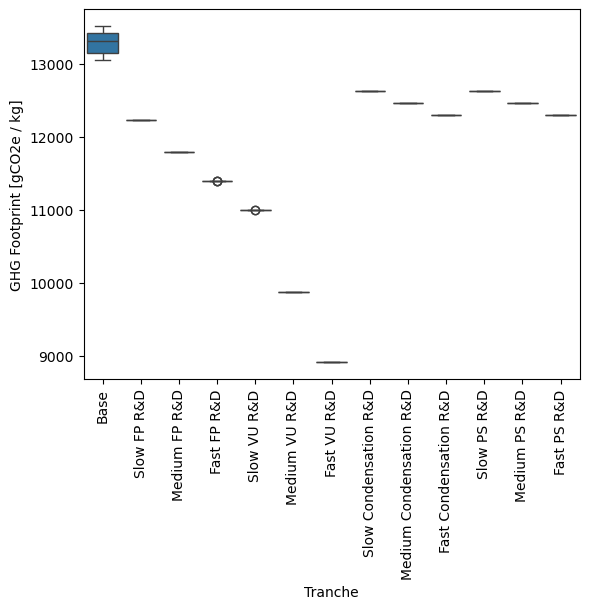

In [18]:
g = sb.boxplot(
    x="Tranche",
    y="Value",
    data=tranche_results.xs(
        "GHG",
        level="Index"
    ).reset_index()[["Tranche", "Value"]],
    order=["Base", "Slow FP R&D", "Medium FP R&D", "Fast FP R&D", "Slow VU R&D", "Medium VU R&D", "Fast VU R&D", "Slow Condensation R&D", "Medium Condensation R&D", "Fast Condensation R&D", "Slow PS R&D", "Medium PS R&D", "Fast PS R&D"]
)
g.set(ylabel="GHG Footprint [gCO2e / kg]")
g.set_xticklabels(g.get_xticklabels(), rotation=90);

### Plot cost metric.

C:\Users\dwright\AppData\Local\Temp\1\ipykernel_21996\4105215006.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), rotation=90);


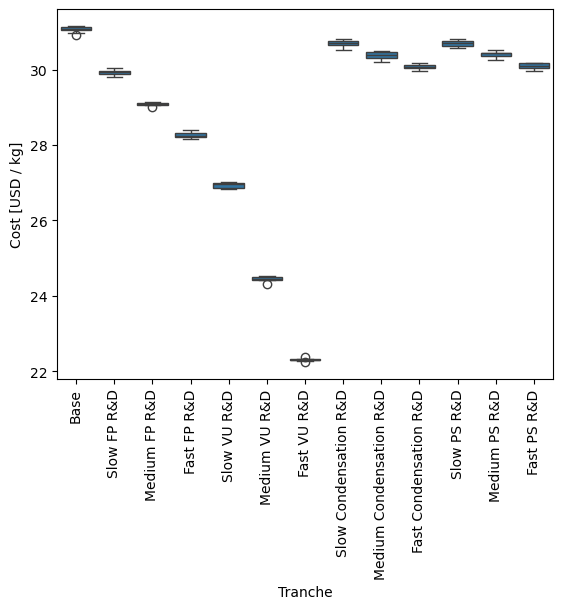

In [19]:
g = sb.boxplot(
    x="Tranche",
    y="Value",
    data=tranche_results.xs(
        "Cost",
        level="Index"
    ).reset_index()[["Tranche", "Value"]],
    order=["Base", "Slow FP R&D", "Medium FP R&D", "Fast FP R&D", "Slow VU R&D", "Medium VU R&D", "Fast VU R&D", "Slow Condensation R&D", "Medium Condensation R&D", "Fast Condensation R&D", "Slow PS R&D", "Medium PS R&D", "Fast PS R&D"]
)
g.set(ylabel="Cost [USD / kg]")
g.set_xticklabels(g.get_xticklabels(), rotation=90);

### Plot employment metric.

C:\Users\dwright\AppData\Local\Temp\1\ipykernel_21996\2345366495.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), rotation=90);


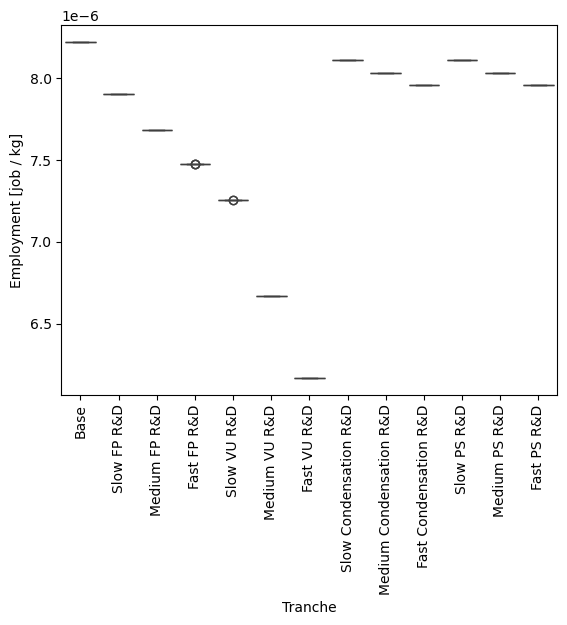

In [20]:
g = sb.boxplot(
    x="Tranche",
    y="Value",
    data=tranche_results.xs(
        "Jobs",
        level="Index"
    ).reset_index()[["Tranche", "Value"]],
    order=["Base", "Slow FP R&D", "Medium FP R&D", "Fast FP R&D", "Slow VU R&D", "Medium VU R&D", "Fast VU R&D", "Slow Condensation R&D", "Medium Condensation R&D", "Fast Condensation R&D", "Slow PS R&D", "Medium PS R&D", "Fast PS R&D"]
)
g.set(ylabel="Employment [job / kg]")
g.set_xticklabels(g.get_xticklabels(), rotation=90);

## Evaluate the investments in the dataset.

In [21]:
investment_results = investments.evaluate_investments(designs, sample_count=50)

Evaluating Pyrolysis
Evaluating Pyrolysis


In [22]:
%tb

No traceback available to show.


### Costs of investments.

In [23]:
investment_results.amounts

,Amount
Investment,
Fast Progress,4000000.0
Medium Progress,2000000.0
No progress,0.0
Slow Progress,400000.0


### Benefits of investments.

In [24]:
investment_results.metrics.xs(1, level="Sample", drop_level=False)

Value  \
Investment      Category             Tranche                 Sample Technology Index                 
Fast Progress   R&D CFP Condensation Fast Condensation R&D   1      Pyrolysis  Cost     138.212166   
                                                                               GHG    12300.371505   
                                                                               Jobs       0.000008   
                R&D CFP FP           Fast FP R&D             1      Pyrolysis  Cost     129.741002   
                                                                               GHG    11389.158608   
                                                                               Jobs       0.000007   
                R&D CFP PS           Fast PS R&D             1      Pyrolysis  Cost     139.073190   
                                                                               GHG    12300.541512   
                                                                               Jobs       0.000008   
                R&D CFP VU           Fast VU R&D             1      Pyrolysis  Cost     106.240739   
                                                                               GHG     8916.882681   
                                                                               Jobs       0.000006   
Medium Progress R&D CFP Condensation Medium Condensation R&D 1      Pyrolysis  Cost     139.759010   
                                                                               GHG    12459.578630   
                                                                               Jobs       0.000008   
                R&D CFP FP           Medium FP R&D           1      Pyrolysis  Cost     134.009798   
                                                                               GHG    11796.987698   
                                                                               Jobs       0.000008   
                R&D CFP PS           Medium PS R&D           1      Pyrolysis  Cost     140.063891   
                                                                               GHG    12459.447400   
                                                                               Jobs       0.000008   
                R&D CFP VU           Medium VU R&D           1      Pyrolysis  Cost     115.353626   
                                                                               GHG     9872.833373   
                                                                               Jobs       0.000007   
No progress     R&D CFP              Base                    1      Pyrolysis  Cost     143.422687   
                                                                               GHG    13021.523122   
                                                                               Jobs       0.000008   
Slow Progress   R&D CFP Condensation Slow Condensation R&D   1      Pyrolysis  Cost     141.360539   
                                                                               GHG    12622.095395   
                                                                               Jobs       0.000008   
                R&D CFP FP           Slow FP R&D             1      Pyrolysis  Cost     138.127050   
                                                                               GHG    12228.831717   
                                                                               Jobs       0.000008   
                R&D CFP PS           Slow PS R&D             1      Pyrolysis  Cost     141.938474   
                                                                               GHG    12622.254157   
                                                                               Jobs       0.000008   
                R&D CFP VU           Slow VU R&D             1      Pyrolysis  Cost     125.695860   
                                                                               GHG    10998.132174   
             

In [25]:
investment_results.summary.xs(1, level="Sample", drop_level=False)

Value     Units
Investment      Technology Sample Index                        
Fast Progress   Pyrolysis  1      Cost     513.267097    USD/kg
                                  GHG    44906.954306  gCO2e/kg
                                  Jobs       0.000030    job/kg
Medium Progress Pyrolysis  1      Cost     529.186325    USD/kg
                                  GHG    46588.847101  gCO2e/kg
                                  Jobs       0.000030    job/kg
No progress     Pyrolysis  1      Cost     143.422687    USD/kg
                                  GHG    13021.523122  gCO2e/kg
                                  Jobs       0.000008    job/kg
Slow Progress   Pyrolysis  1      Cost     547.121923    USD/kg
                                  GHG    48471.313443  gCO2e/kg
                                  Jobs       0.000031    job/kg

### Save results.

In [26]:
#investment_results.amounts.to_csv("example-investment-amounts.csv")

In [27]:
#investment_results.metrics.to_csv("example-investment-metrics.csv")

### Plot GHG metric.

C:\Users\dwright\AppData\Local\Temp\1\ipykernel_21996\3834033868.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), rotation=90);


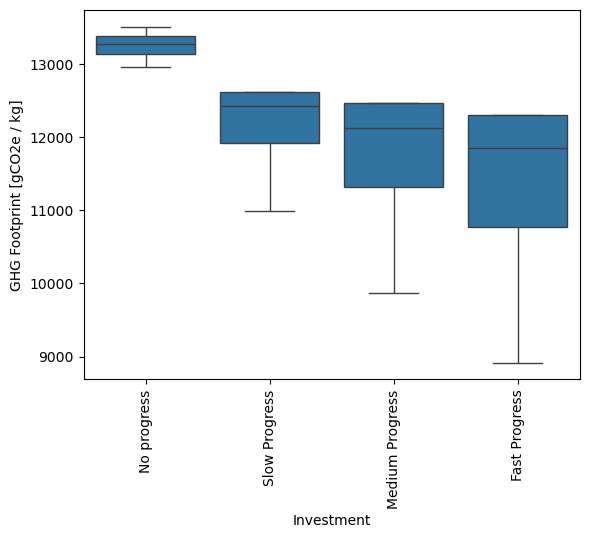

In [28]:
g = sb.boxplot(
    x="Investment",
    y="Value",
    data=investment_results.metrics.xs(
        "GHG",
        level="Index"
    ).reset_index()[["Investment", "Value"]],
    order=["No progress", "Slow Progress", "Medium Progress", "Fast Progress"]
)
g.set(ylabel="GHG Footprint [gCO2e / kg]")
g.set_xticklabels(g.get_xticklabels(), rotation=90);

### Plot cost metric.

C:\Users\dwright\AppData\Local\Temp\1\ipykernel_21996\2125269719.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), rotation=90);


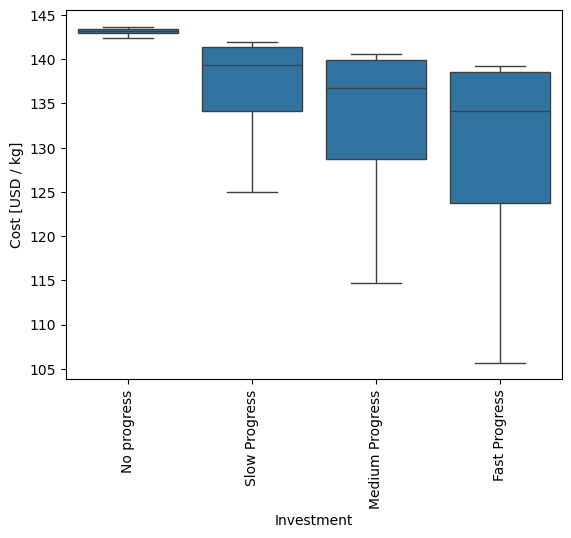

In [29]:
g = sb.boxplot(
    x="Investment",
    y="Value",
    data=investment_results.metrics.xs(
        "Cost",
        level="Index"
    ).reset_index()[["Investment", "Value"]],
    order=["No progress", "Slow Progress", "Medium Progress", "Fast Progress"]
)
g.set(ylabel="Cost [USD / kg]")
g.set_xticklabels(g.get_xticklabels(), rotation=90);

### Plot employment metric.

C:\Users\dwright\AppData\Local\Temp\1\ipykernel_21996\1003216871.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), rotation=90);


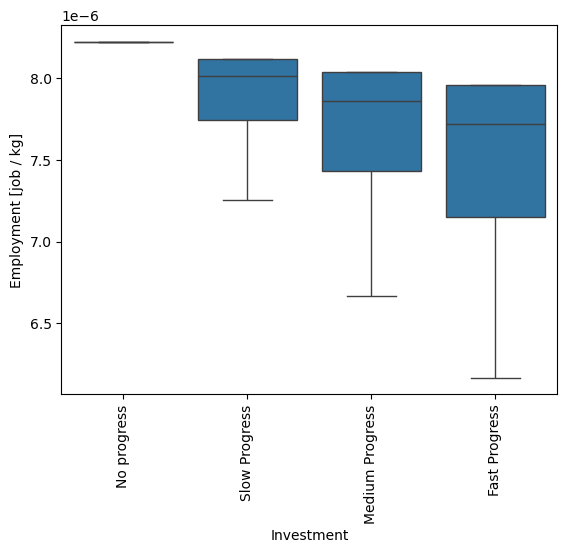

In [30]:
g = sb.boxplot(
    x="Investment",
    y="Value",
    data=investment_results.metrics.xs(
        "Jobs",
        level="Index"
    ).reset_index()[["Investment", "Value"]],
    order=["No progress", "Slow Progress", "Medium Progress", "Fast Progress"]
)
g.set(ylabel="Employment [job / kg]")
g.set_xticklabels(g.get_xticklabels(), rotation=90);

## Sensitivity analysis.

### Vary the efficiencies in the design.

In [31]:
# Seven variables are involved.
variables = [
    ("Input efficiency" , "Biomass"),
    ("Input efficiency" , "Hydrogen"),
    ("Input efficiency" , "Steam"),
    ("Input efficiency" , "Catalyst"),
    ("Output efficiency", "Jet fuel"),
    ("Output efficiency", "Gasoline"),
    ("Output efficiency", "Diesel")
]

In [32]:
# Let efficiencies range from 0.75 to 0.975.
efficiencies = np.arange(0.750, 1.000, 0.025)
efficiencies

array([0.75 , 0.775, 0.8  , 0.825, 0.85 , 0.875, 0.9  , 0.925, 0.95 ,
       0.975])

### Start from the base case.

In [33]:
base_design = designs.designs.xs("Base", level=1, drop_level=False)
base_design

Value  \
Technology Tranche Variable          Index                                          
Pyrolysis  Base    Input             Biomass                               183718   
                                     Catalyst                              183718   
                                     Hydrogen                                2471   
                                     Steam                                    360   
                   Input efficiency  Biomass                                    1   
                                     Catalyst                                   1   
                                     Hydrogen                                   1   
                                     Steam                                      1   
                   Input price       Biomass                                0.114   
                                     Catalyst                               0.114   
                                     Hydrogen                             0.00022   
                                     Steam                                0.00022   
                   Lifetime          BOS                 st.triang(0.3, 8.0, 0.1)   
                                     Condensation        st.triang(0.3, 8.0, 0.1)   
                                     Fast Pyrolysis      st.triang(0.3, 8.0, 0.1)   
                                     Product Separation  st.triang(0.3, 8.0, 0.1)   
                                     Vapor Upgrading     st.triang(0.3, 8.0, 0.1)   
                   Output efficiency Diesel                                     1   
                                     Gasoline                                   1   
                                     Jet fuel                                   1   
                   Output price      Diesel                                  1.03   
                                     Gasoline                                   1   
                                     Jet fuel                                4.41   
                   Scale             Complete Plant                             1   

                                                            Units Notes  
Technology Tranche Variable          Index                               
Pyrolysis  Base    Input             Biomass                lb/hr   NaN  
                                     Catalyst               lb/hr   NaN  
                                     Hydrogen               lb/hr   NaN  
                                     Steam                  lb/hr   NaN  
                   Input efficiency  Biomass             unitless   NaN  
                                     Catalyst            unitless   NaN  
                                     Hydrogen            unitless   NaN  
                                     Steam               unitless   NaN  
                   Input price       Biomass                 $/lb   NaN  
                                     Catalyst                $/lb   NaN  
                                     Hydrogen                $/lb   NaN  
                                     Steam                   $/lb   NaN  
                   Lifetime          BOS                    years   NaN  
                                     Condensation           years   NaN  
                                     Fast Pyrolysis         years   NaN  
                                     Product Separation     years   NaN  
                                     Vapor Upgrading        years   NaN  
                   Output efficiency Diesel                  unit   NaN  
                                     Gasoline                unit   NaN  
                                     Jet fuel                unit   NaN  
                   Output price      Diesel                  $/lb   NaN  
                                     Gasoline                $/lb   NaN  
                                     Jet fuel                $/lb   NaN  
               

In [34]:
base_parameters = designs.parameters.xs("Base", level=1, drop_level=False)
base_parameters

Offset  \
Technology Tranche Parameter                         
Pyrolysis  Base    BOS                          10   
                   Condensation design           2   
                   FP design                     0   
                   Jet_conversion                4   
                   PS design                     3   
                   VU design                     1   
                   diesel conversion             8   
                   gasoline conversion           9   
                   ghg ef                        6   
                   jet fuel energy content       5   
                   job factor                    7   

                                                                       Value  \
Technology Tranche Parameter                                                   
Pyrolysis  Base    BOS                                                     1   
                   Condensation design                                     1   
                   FP design                                               1   
                   Jet_conversion                                     0.1216   
                   PS design                                               1   
                   VU design                                               1   
                   diesel conversion                                  0.0555   
                   gasoline conversion                                0.0687   
                   ghg ef                                                 68   
                   jet fuel energy content  st.triang(1, loc=46.5, scale=10)   
                   job factor                                           1000   

                                                                   Units  \
Technology Tranche Parameter                                               
Pyrolysis  Base    BOS                                                 1   
                   Condensation design                                 1   
                   FP design                                           1   
                   Jet_conversion                kg Jet Fuel/ kg Biomass   
                   PS design                                           1   
                   VU design                                           1   
                   diesel conversion          kg Diesel Fuel/ kg Biomass   
                   gasoline conversion      kg Gasoline Fuel/ kg Biomass   
                   ghg ef                                     gco2eq./MJ   
                   jet fuel energy content                         MJ/kg   
                   job factor                                        job   

                                                 Notes  
Technology Tranche Parameter                            
Pyrolysis  Base    BOS                             bos  
                   Condensation design             con  
                   FP design                        fp  
                   Jet_conversion           conversion  
                   PS design                        ps  
                   VU design                        vu  
                   diesel conversion        conversion  
                   gasoline conversion      conversion  
                   ghg ef                          ghg  
                   jet fuel energy content         jet  
                   job factor                      job

### Generate the new tranches and append them to the previous ones.

In [35]:
sensitivities = deepcopy(designs)
sensitivities.designs = sensitivities.designs[0:0]
sensitivities.parameters = sensitivities.parameters[0:0]

In [36]:
# Iterate over variables and efficiencies.
for variable, index in variables:
    for efficiency in efficiencies:

        # Name the tranche.
        tranche = "Let " + variable + " @ " + index + " = " + str(round(efficiency, 3))
        
        # Alter the base case.
        vary_design = base_design.rename(index={"Base" : tranche}, level=1)
        vary_design.loc[("Pyrolysis", tranche, variable, index), "Value"] = efficiency
        
        # Keep the parameters the same.
        vary_parameters = base_parameters.rename(index={"Base" : tranche}, level=1)
        
        # Append the results to the existing table of scenarios.
        sensitivities.designs = pd.concat([sensitivities.designs, vary_design])
        sensitivities.parameters = pd.concat([sensitivities.parameters, vary_parameters])

#### Remember to compile the design, since we've added scenarios.

In [37]:
sensitivities.compile()

#### See how many rows there are in the tables now.

In [38]:
sensitivities.designs.shape

(1680, 3)

In [39]:
sensitivities.parameters.shape

(770, 4)

In [40]:
sensitivities.designs

Value  \
Technology Tranche                                Variable          Index                    
Pyrolysis  Let Input efficiency @ Biomass = 0.75  Input             Biomass         183718   
                                                                    Catalyst        183718   
                                                                    Hydrogen          2471   
                                                                    Steam              360   
                                                  Input efficiency  Biomass           0.75   
...                                                                                    ...   
           Let Output efficiency @ Diesel = 0.975 Output efficiency Jet fuel             1   
                                                  Output price      Diesel            1.03   
                                                                    Gasoline             1   
                                                                    Jet fuel          4.41   
                                                  Scale             Complete Plant       1   

                                                                                       Units  \
Technology Tranche                                Variable          Index                      
Pyrolysis  Let Input efficiency @ Biomass = 0.75  Input             Biomass            lb/hr   
                                                                    Catalyst           lb/hr   
                                                                    Hydrogen           lb/hr   
                                                                    Steam              lb/hr   
                                                  Input efficiency  Biomass         unitless   
...                                                                                      ...   
           Let Output efficiency @ Diesel = 0.975 Output efficiency Jet fuel            unit   
                                                  Output price      Diesel              $/lb   
                                                                    Gasoline            $/lb   
                                                                    Jet fuel            $/lb   
                                                  Scale             Complete Plant      unit   

                                                                                   Notes  
Technology Tranche                                Variable          Index                 
Pyrolysis  Let Input efficiency @ Biomass = 0.75  Input             Biomass          NaN  
                                                                    Catalyst         NaN  
                                                                    Hydrogen         NaN  
                                                                    Steam            NaN  
                                                  Input efficiency  Biomass          NaN  
...                                                                                  ...  
           Let Output efficiency @ Diesel = 0.975 Output efficiency Jet fuel         NaN  
                                                  Output price      Diesel           NaN  
                                                                    Gasoline         NaN  
                                                                    Jet fuel         NaN  
                                                  Scale             Complete Plant   NaN  

[1680 rows x 3 columns]

### Compute the results.

In [41]:
results = sensitivities.evaluate_tranche_impacts(1)
results

Evaluating Pyrolysis


Value  \
Technology Tranche                                  Sample Variable Index                    
Pyrolysis  Let Input efficiency @ Biomass = 0.75    1      Cost     Cost     -3.938588e+08   
                                                           Metric   Cost      2.741131e+01   
                                                                    GHG       1.338248e+04   
                                                                    Jobs      1.096494e-05   
                                                           Output   Diesel    2.747242e+07   
...                                                                                    ...   
           Let Output efficiency @ Jet fuel = 0.975 1      Metric   GHG       1.334826e+04   
                                                                    Jobs      8.434573e-06   
                                                           Output   Diesel    3.662989e+07   
                                                                    Gasoline  4.534187e+07   
                                                                    Jet fuel  1.185597e+08   

                                                                                 Units  
Technology Tranche                                  Sample Variable Index               
Pyrolysis  Let Input efficiency @ Biomass = 0.75    1      Cost     Cost        USD/kg  
                                                           Metric   Cost        USD/kg  
                                                                    GHG       gCO2e/kg  
                                                                    Jobs        job/kg  
                                                           Output   Diesel          kg  
...                                                                                ...  
           Let Output efficiency @ Jet fuel = 0.975 1      Metric   GHG       gCO2e/kg  
                                                                    Jobs        job/kg  
                                                           Output   Diesel          kg  
                                                                    Gasoline        kg  
                                                                    Jet fuel        kg  

[490 rows x 2 columns]

### Plot the cost results.

In [42]:
# cost_results = results.xs("Cost", level="Index").reset_index()[["Tranche", "Value"]]

In [43]:
# changing cost from Designs.py "Cost" to Pyrolysis.py "Metrics > Cost"
cost_results = results.xs("Metric", level="Variable").xs("Cost", level="Index").reset_index()[["Tranche", "Value"]]

In [44]:
cost_results[0:10]

,Tranche,Value
0,Let Input efficiency @ Biomass = 0.75,27.411313
1,Let Input efficiency @ Biomass = 0.775,26.617221
2,Let Input efficiency @ Biomass = 0.8,25.813692
3,Let Input efficiency @ Biomass = 0.825,25.071463
4,Let Input efficiency @ Biomass = 0.85,24.370389
5,Let Input efficiency @ Biomass = 0.875,23.639342
6,Let Input efficiency @ Biomass = 0.9,22.994282
7,Let Input efficiency @ Biomass = 0.925,22.516118
8,Let Input efficiency @ Biomass = 0.95,21.909052
9,Let Input efficiency @ Biomass = 0.975,21.401325


In [45]:
cost_results["Variable"  ] = cost_results["Tranche"].apply(lambda x: re.sub(r'^Let (.*) @ (.*) =.*$', '\\1[\\2]', x))
cost_results["Efficiency"] = cost_results["Tranche"].apply(lambda x: float(re.sub(r'^.*= (.*)$', '\\1', x)))
cost_results["Cost [USD/kg]"] = cost_results["Value"]

In [46]:
cost_results = cost_results[["Variable", "Efficiency", "Cost [USD/kg]"]]
cost_results[0:10]

,Variable,Efficiency,Cost [USD/kg]
0,Input efficiency[Biomass],0.750,27.411313
1,Input efficiency[Biomass],0.775,26.617221
2,Input efficiency[Biomass],0.800,25.813692
3,Input efficiency[Biomass],0.825,25.071463
4,Input efficiency[Biomass],0.850,24.370389
5,Input efficiency[Biomass],0.875,23.639342
6,Input efficiency[Biomass],0.900,22.994282
7,Input efficiency[Biomass],0.925,22.516118
8,Input efficiency[Biomass],0.950,21.909052
9,Input efficiency[Biomass],0.975,21.401325


<AxesSubplot: xlabel='Efficiency', ylabel='Cost [USD/kg]'>

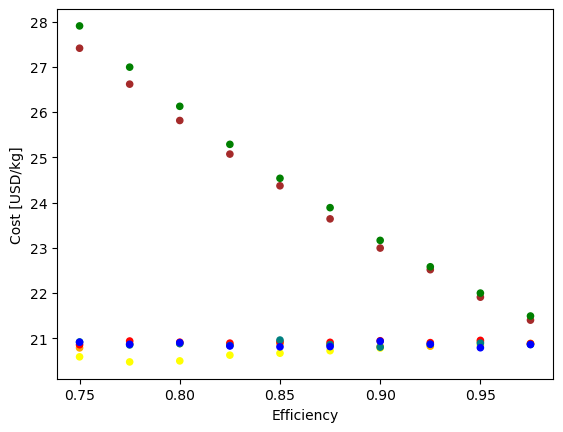

In [47]:
# Here is a really simple plot.
cost_results.plot(
    x="Efficiency",
    y="Cost [USD/kg]",
    c=cost_results["Variable"].apply(lambda v: {
        "Input efficiency[Biomass]"       : "brown"  ,
        "Input efficiency[Hydrogen]" : "orange",
        "Input efficiency[Steam]" : "red",
        "Input efficiency[Catalyst]" : "yellow",
        "Output efficiency[Jet fuel]"     : "green" ,
        "Output efficiency[Gasoline]"   : "blue"   ,
        "Output efficiency[Diesel]"   : "teal"   ,
    }[v]),
    kind="scatter"
)